> # Tensorflow - Exercise

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split 
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

plt.style.use('fivethirtyeight')

>> Load the data

In [47]:
data = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [49]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


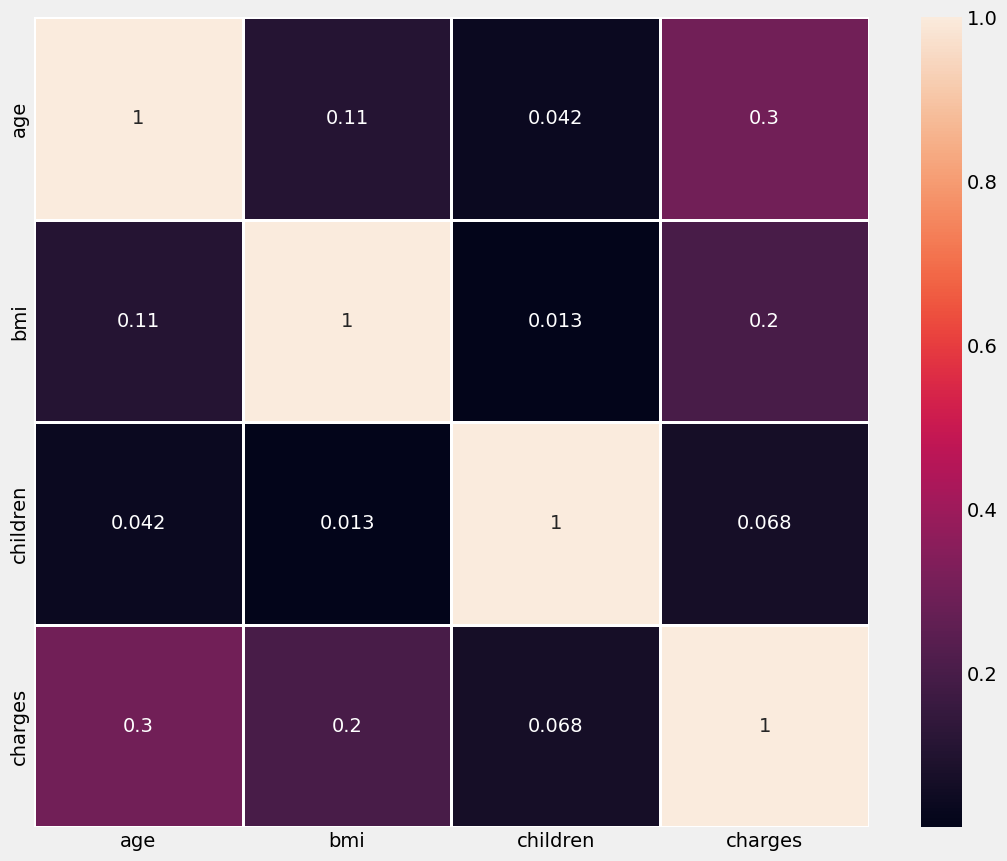

In [50]:
plt.figure(figsize = (12,10))
sns.heatmap((data.select_dtypes(exclude = "object")).corr(),annot = True,linewidth = 1)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_11900\485087629.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["charges"])


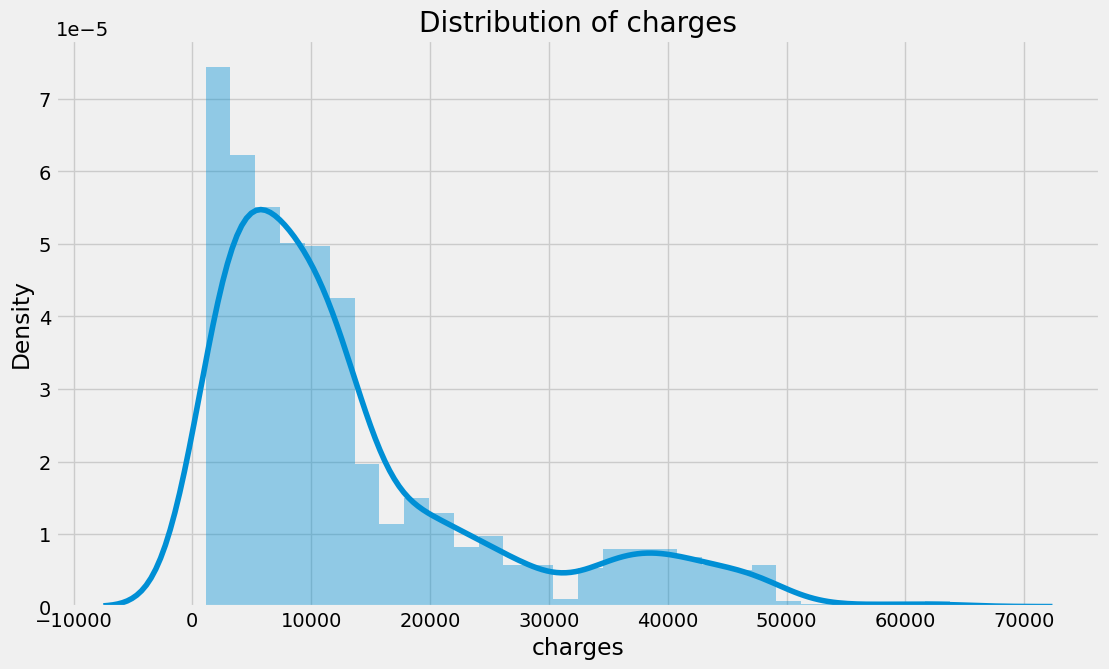

In [51]:
plt.figure(figsize=  (12,7))
sns.distplot(data["charges"])
plt.title("Distribution of charges")
plt.show()

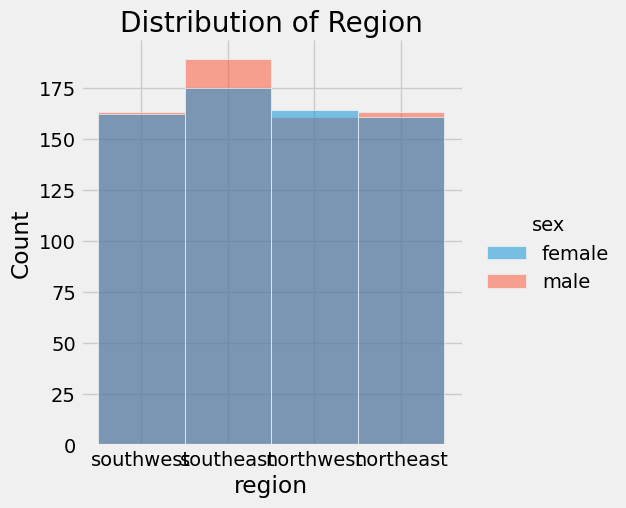

In [52]:
sns.displot(data = data,x = "region",hue="sex")
plt.title("Distribution of Region")
plt.show()

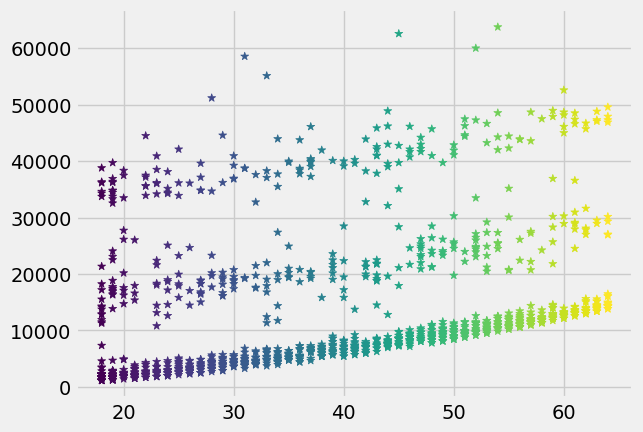

In [53]:
plt.scatter(data=data,x = "age",y = "charges",c="age",marker = "*")
plt.show()

In [54]:
age_18_25 = data.age[(data.age>=18)&(data.age<=25)]
age_26_35 = data.age[(data.age>=26)&(data.age<=35)]
age_36_45 = data.age[(data.age>=36)&(data.age<=45)]
age_46_55 = data.age[(data.age>=46)&(data.age<=55)]
age_55_above = data.age[data.age>55]

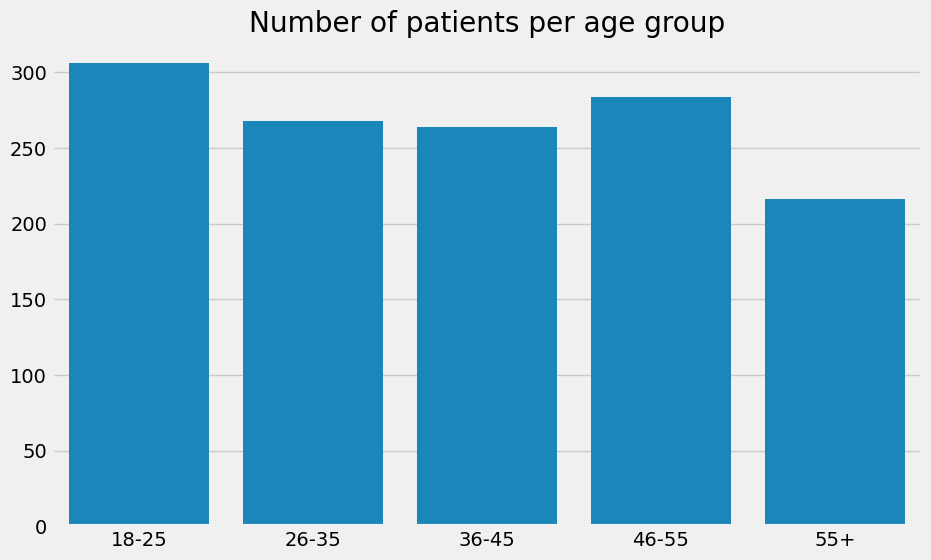

In [55]:
x_age= ["18-25","26-35","36-45","46-55","55+"]
y_age = [len(age_18_25),len(age_26_35),len(age_36_45),len(age_46_55),len(age_55_above)]
plt.figure(figsize=(10,6))
sns.barplot(x = x_age,y = y_age,)
plt.title("Number of patients per age group")
plt.show()

Text(0.5, 1.0, 'Gender and Charge Distribution')

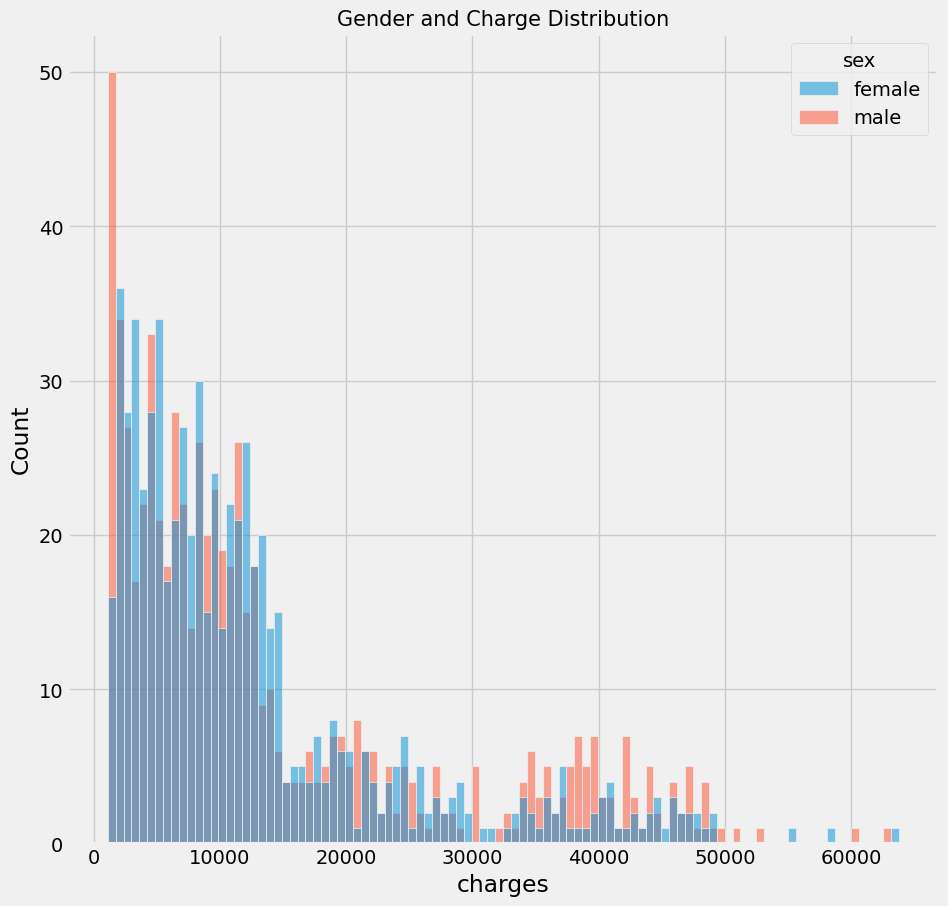

In [56]:
plt.figure(figsize=(10,10))
sns.histplot(data = data,bins = 100,x = "charges",hue = "sex")
plt.title("Gender and Charge Distribution",fontsize= 15)

Text(0.5, 1.0, 'Gender and Charges')

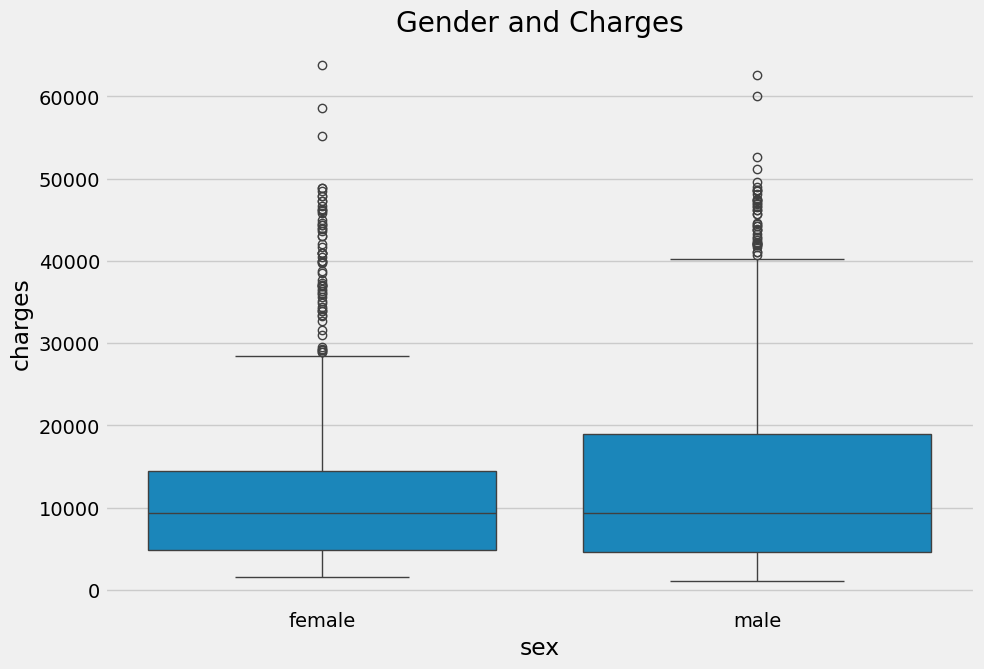

In [57]:
plt.figure(figsize = (10,7))
sns.boxplot(data = data,x = "sex",y = "charges")
plt.title("Gender and Charges")

Text(0.5, 1.0, 'Gender and Charges')

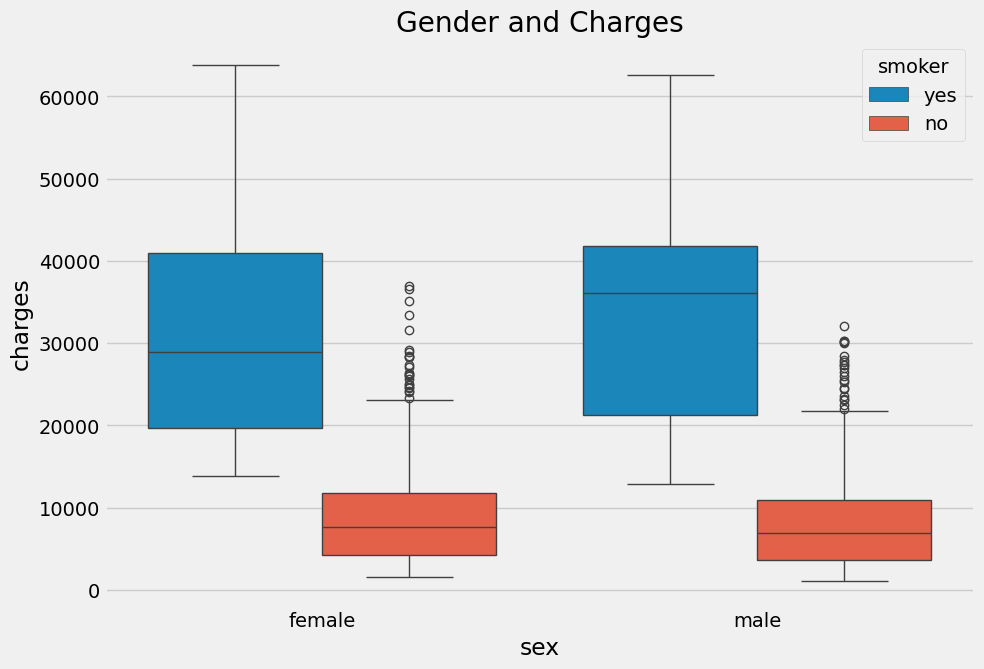

In [58]:
plt.figure(figsize = (10,7))
sns.boxplot(data = data,x = "sex",y = "charges",hue = "smoker")
plt.title("Gender and Charges")

<Figure size 1000x700 with 0 Axes>

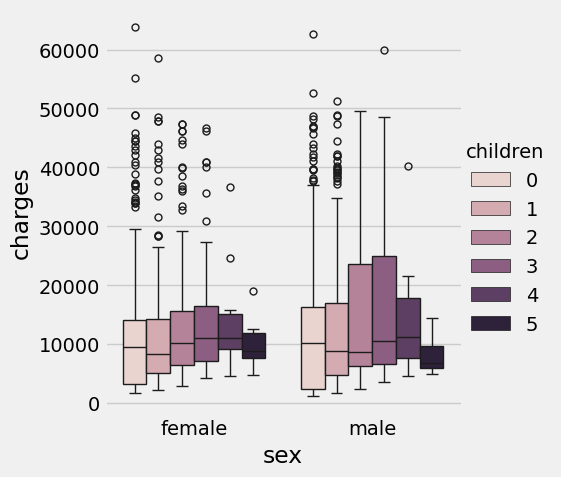

In [59]:
plt.figure(figsize = (10,7))
sns.catplot(data = data,x = "sex",y = "charges",hue = "children",kind="box")
plt.show()

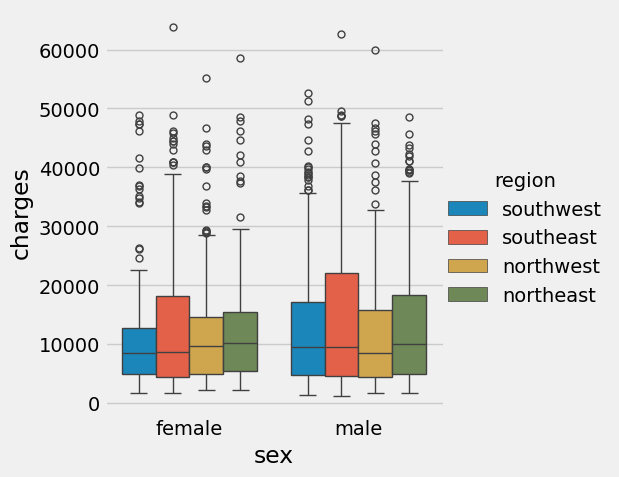

In [60]:
sns.catplot(data =data,x = "sex", y= "charges",hue = "region",kind = "box")
plt.show()

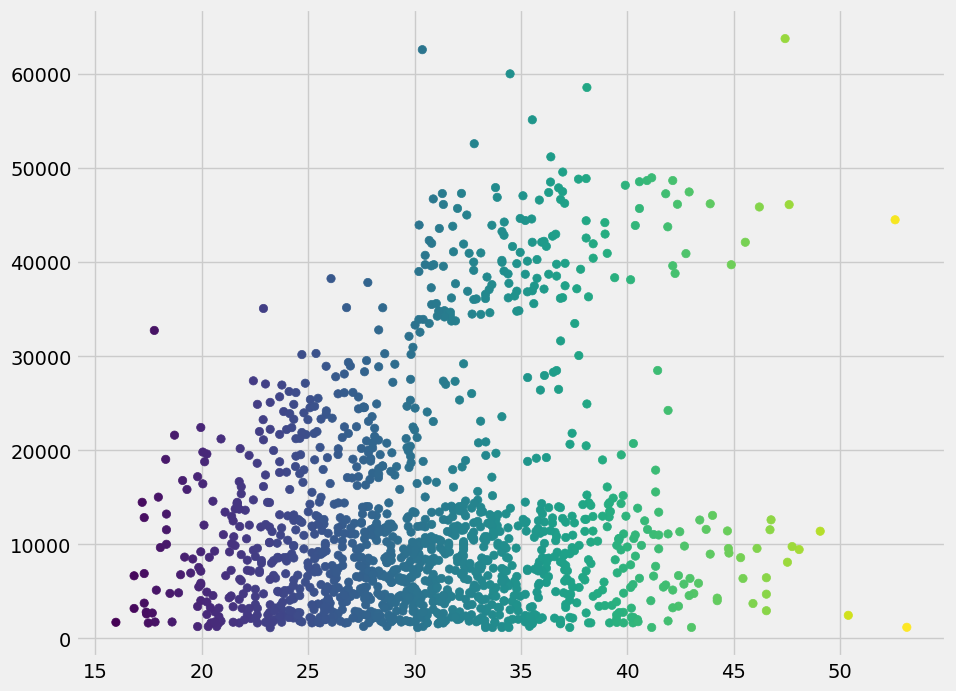

In [61]:
plt.figure(figsize=(10,8))
plt.scatter(data = data,x = "bmi",y ="charges",c = "bmi")
plt.show()

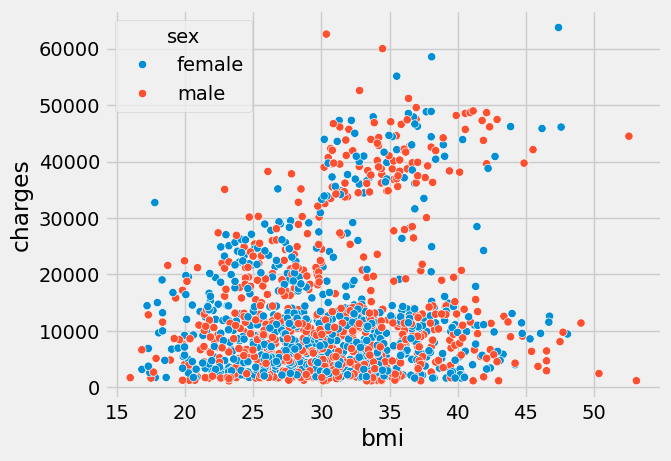

In [62]:
sns.scatterplot(data = data,x = "bmi",y = "charges",hue = "sex")
plt.show()

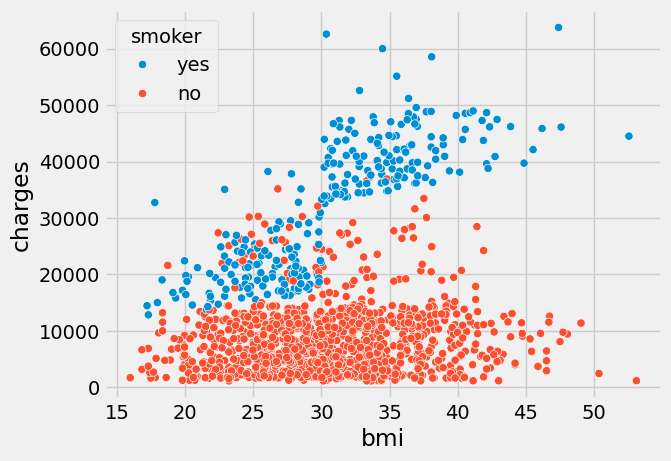

In [63]:
sns.scatterplot(data = data,x = "bmi",y = "charges",hue = "smoker")
plt.show()

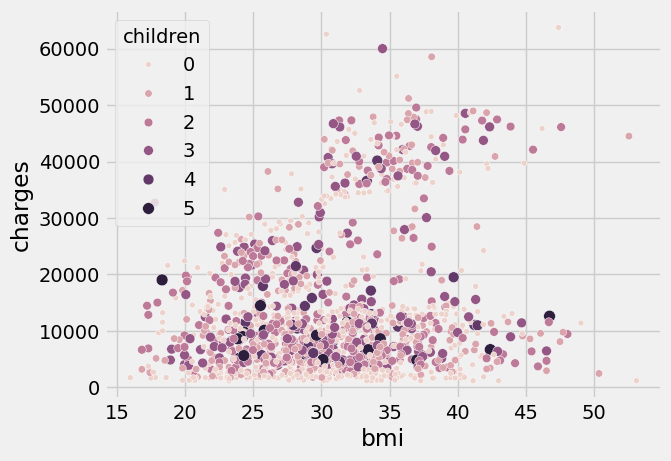

In [67]:
sns.scatterplot(data =data,size="children",x = "bmi",y= "charges",hue = "children")
plt.show()

In [68]:
data_children = data.groupby("children")["charges"].mean().reset_index()
data_children

,children,charges
0,0,12365.975602
1,1,12731.171832
2,2,15073.563734
3,3,15355.318367
4,4,13850.656311
5,5,8786.035247


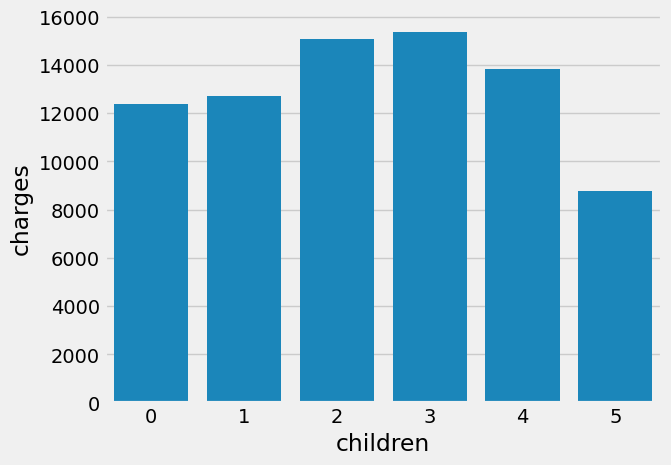

In [72]:
sns.barplot(data =data_children,x = "children", y = "charges")
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

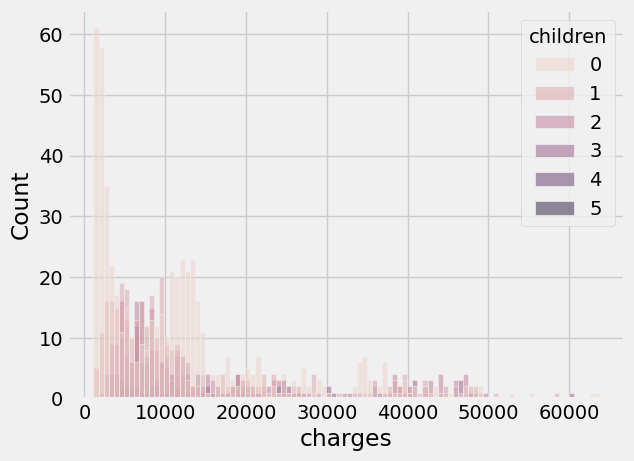

In [77]:
sns.histplot(data =data,x = "charges",bins=100,hue = "children")

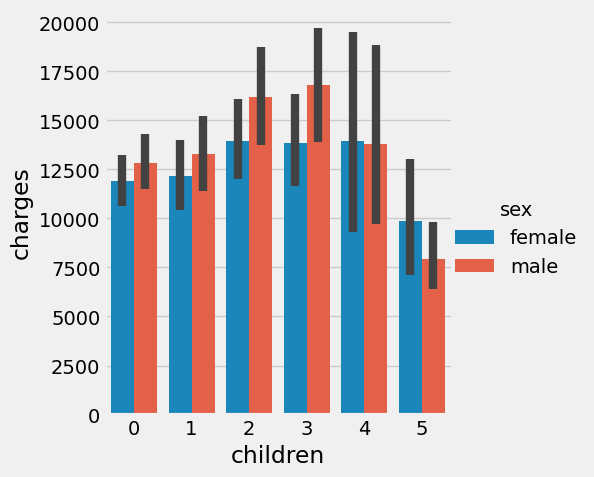

In [81]:
sns.catplot(kind="bar",x = "children",y ="charges",data =data,hue=  "sex")
plt.show()

<Axes: xlabel='children', ylabel='bmi'>

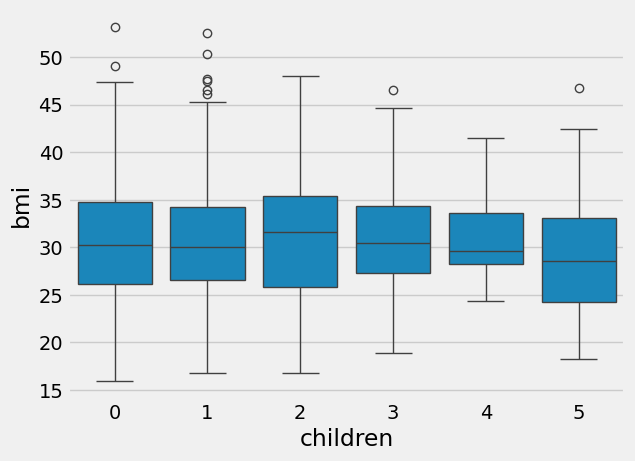

In [83]:
sns.boxplot(data = data,x = "children",y = "bmi")

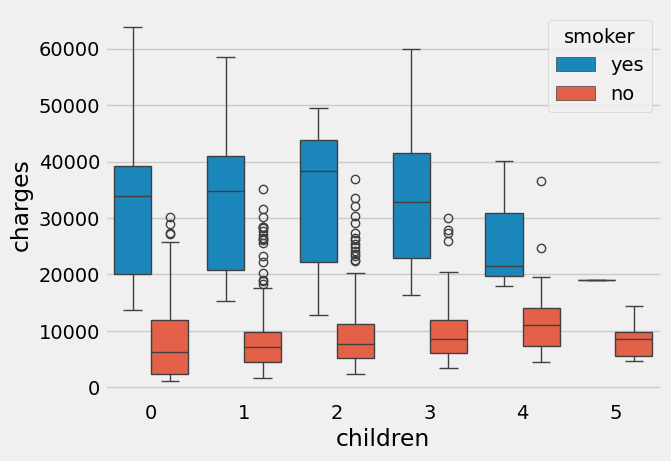

In [88]:
sns.boxplot(data = data,x = "children",y ="charges",hue = "smoker")
plt.show()

<Axes: xlabel='children', ylabel='charges'>

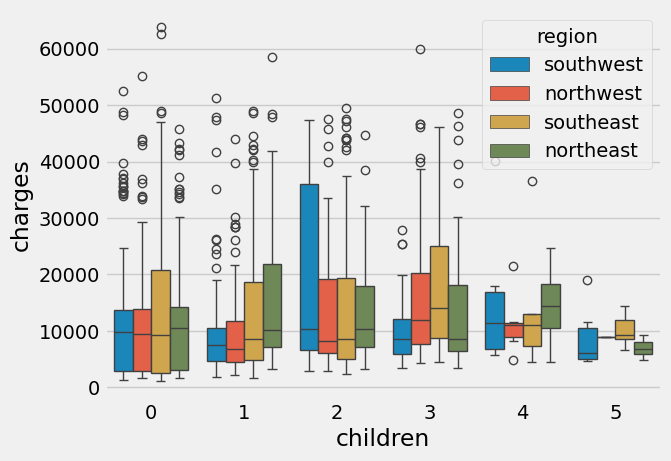

In [89]:
sns.boxplot(data = data,x = "children",y ="charges",hue ="region")

<Axes: xlabel='smoker', ylabel='charges'>

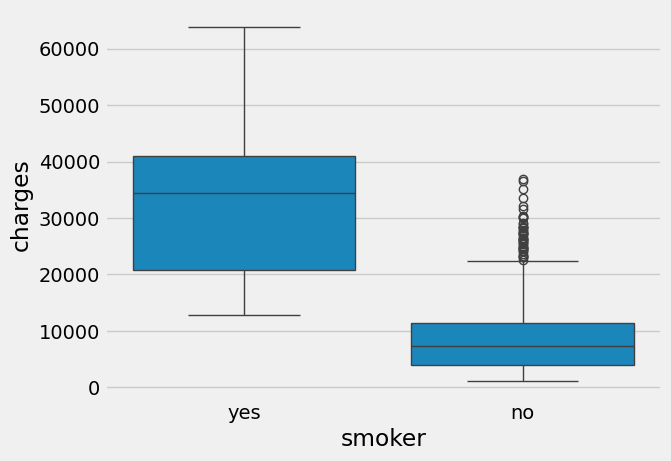

In [90]:
sns.boxplot(data =data,x  = "smoker",y = "charges")

In [92]:
ct = make_column_transformer((MinMaxScaler(),["age","children","bmi"]),
                             (OneHotEncoder(handle_unknown="ignore"),["sex","region","smoker"]))

X = data.drop("charges",axis = 1)
y = data.charges
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)

In [93]:
X_train_scaled,X_test_scaled

(array([[0.60869565, 0.4       , 0.10734463, ..., 0.        , 1.        ,
         0.        ],
        [0.63043478, 0.        , 0.22491256, ..., 0.        , 1.        ,
         0.        ],
        [0.73913043, 0.        , 0.23944041, ..., 0.        , 1.        ,
         0.        ],
        ...,
        [0.86956522, 0.        , 0.24791499, ..., 0.        , 1.        ,
         0.        ],
        [0.41304348, 0.4       , 0.85122411, ..., 1.        , 0.        ,
         1.        ],
        [0.80434783, 0.        , 0.37503363, ..., 1.        , 1.        ,
         0.        ]], shape=(1070, 11)),
 array([[0.58695652, 0.4       , 0.24791499, ..., 0.        , 1.        ,
         0.        ],
        [0.39130435, 0.        , 0.37826204, ..., 0.        , 1.        ,
         0.        ],
        [1.        , 0.        , 0.29391983, ..., 0.        , 0.        ,
         1.        ],
        ...,
        [0.43478261, 0.2       , 0.32458972, ..., 0.        , 1.        ,
         0.     

In [94]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(300,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(200,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(100,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(50,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])

model.compile(loss =tf.keras.losses.mae,optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),metrics =["mae"])

model_history = model.fit(X_train_scaled,y_train,epochs = 500)

model.evaluate(X_test_scaled,y_test)

model.summary()


Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 9316.9297 - mae: 9316.9297  
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4624.4194 - mae: 4624.4194
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3716.1938 - mae: 3716.1938
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3510.4324 - mae: 3510.4324
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3274.4802 - mae: 3274.4802
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3301.0129 - mae: 3301.0129
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3159.6697 - mae: 3159.6697
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2984.7571 - mae: 2984.7571
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2740.0879 - mae: 2740.0879
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2584.5376 - mae: 2584.5376
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2555.4907 - mae: 2555.4907
Epoch 12/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,415 (1.02 MB)

 Trainable params: 89,471 (349.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 178,944 (699.00 KB)